# Stablecoin Depeg Early Warning System
## Predictive Modelling

Reads the pooled feature dataset from S3 and builds two CatBoost classifiers
plus an Isolation Forest novelty detector. Evaluation uses coin-stratified
chronological train/val/test splits and Leave-One-Event-Out cross-validation
on five confirmed historical crisis events.

**Targets:**
- Model 1: `depeg_next_1h`   — fires up to 1 hour before depeg onset
- Model 2: `depeg_next_30min` — fires up to 30 minutes before depeg onset

## 1. Setup

In [1]:
import gc
import pickle
import psutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from catboost import CatBoostClassifier, Pool
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve
)
import shap
import warnings, time

warnings.filterwarnings("ignore")
shap.initjs()

# plot style 
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi":        130,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#FAFAFA",
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10.5,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "legend.framealpha": 0.85,
})

# colour palette 
ORANGE = "#F5AC37"
RED    = "#E84142"
GREEN  = "#27AE60"
DARK   = "#2C3E50"
LGRAY  = "#BDC3C7"
ACCENT = "#2775CA"

COIN_COLORS = {
    "usdt":  "#26A17B",
    "usdc":  "#2775CA",
    "dai":   "#F5AC37",
    "busd":  "#F0B90B",
    "ust":   "#E84142",
    "usde":  "#9B59B6",
    "rlusd": "#00AAE4",
}

COINS = ["usdt", "usdc", "dai", "busd", "ust", "usde", "rlusd"]

COIN_TYPE = {
    "usdt":  "fiat_backed",
    "usdc":  "fiat_backed",
    "busd":  "fiat_backed",
    "rlusd": "fiat_backed",
    "dai":   "crypto_backed",
    "ust":   "algorithmic",
    "usde":  "yield_bearing",
}

# 5-min bar constants
BARS_1H  = 12

# ── local paths ───────────────────────────────────────────────────────────────
FEATURES_DIR = Path("../data/processed/features")
MODELS_DIR   = Path("../data/models")
PREDS_DIR    = Path("../data/processed/predictions")
PLOTS_DIR    = Path("../data/processed/features")

for folder in [MODELS_DIR, PREDS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# modelling constants 
COIN_WEIGHTS = {
    "usdt":  0.9712,
    "usdc":  0.4163,
    "dai":   2.2798,
    "busd":  0.1277,
    "ust":   1.1562,
    "usde":  0.0707,
    "rlusd": 0.0000,
}

LOEO_EVENTS = [
    ("usdt", "Oct 2018 USDT Reserve Scare", "2018-10-05", "2018-10-22"),
    ("dai",  "Mar 2020 Black Thursday",     "2020-03-10", "2020-03-17"),
    ("ust",  "May 2022 UST Collapse",       "2022-05-06", "2022-05-13"),
    ("usdc", "May 2022 UST Contagion",      "2022-05-06", "2022-05-15"),
    ("usdc", "Mar 2023 SVB Bank Run",       "2023-03-08", "2023-03-15"),
]

LOEO_BUFFER = pd.Timedelta(hours=48)

BASE_CB_PARAMS = dict(
    iterations            = 500,
    depth                 = 6,
    learning_rate         = 0.05,
    loss_function         = "Logloss",
    eval_metric           = "AUC",
    auto_class_weights    = "Balanced",
    early_stopping_rounds = 50,
    random_seed           = 42,
    verbose               = False,
)

LOEO_PARAMS = {
    **BASE_CB_PARAMS,
    "iterations":         200,
    "depth":              5,
    "max_ctr_complexity": 1,
}

def ram_used_gb():
    return psutil.virtual_memory().used / 1e9

print("Setup complete.")
print(f"Input:  {FEATURES_DIR}")
print(f"Output: {MODELS_DIR}")

Setup complete.
Input:  ../data/processed/features
Output: ../data/models


## 2. Download and Load Pooled Dataset

In [2]:
t0 = time.time()

local_pooled = FEATURES_DIR / "pooled_5m.parquet"
if local_pooled.exists():
    print("pooled_5m.parquet found locally")
else:
    print(f"MISSING pooled_5m.parquet — expected at {local_pooled}")

df = pd.read_parquet(local_pooled)

df["u_coin_type"] = df["coin"].map(COIN_TYPE)

print(f"Shape:             {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Coins:             {sorted(df['coin'].unique().tolist())}")
print(f"Date range:        {df.index.min().date()} to {df.index.max().date()}")
print(f"depeg_next_1h:     {df['depeg_next_1h'].mean():.3%} positive rate")
print(f"depeg_next_30min:  {df['depeg_next_30min'].mean():.3%} positive rate")
print(f"Load completed in {time.time()-t0:.1f}s")

pooled_5m.parquet found locally
Shape:             3,101,405 rows x 31 cols
Coins:             ['busd', 'dai', 'rlusd', 'usdc', 'usde', 'usdt', 'ust']
Date range:        2017-08-17 to 2026-02-28
depeg_next_1h:     0.747% positive rate
depeg_next_30min:  0.468% positive rate
Load completed in 0.3s


In [3]:
t0 = time.time()

# identify feature columns — any u_, s_, f_ column except u_coin_type (categorical)
feat_cols = [c for c in df.columns
             if c.startswith(('u_', 's_', 'f_'))
             and c != 'u_coin_type']

cat_cols  = ['u_coin_type']
all_input = feat_cols + cat_cols

print(f'Numeric features:    {len(feat_cols)}')
print(f'Categorical:         {len(cat_cols)}')
print(f'Total model inputs:  {len(all_input)}')

# assign per row sample weights
df['sample_weight'] = df['coin'].map(COIN_WEIGHTS).fillna(0)

print('\nSample weight distribution:')
print(df.groupby('coin')['sample_weight'].first().to_frame().T)
print(f'\nCompleted in {time.time()-t0:.1f}s')

Numeric features:    25
Categorical:         1
Total model inputs:  26

Sample weight distribution:
coin             busd     dai  rlusd    usdc    usde    usdt     ust
sample_weight  0.1277  2.2798    0.0  0.4163  0.0707  0.9712  1.1562

Completed in 0.1s


## 3. Coin-Stratified Chronological Train / Validation / Test Split

**Why stratified?** The global chronological split silently excludes
short-lived coins from validation and test because their full history
falls before the 70% time cut. UST for example exists only Nov 2020
to May 2022, entirely in the train window under a global split.

**Fix:** split each coin's own history 70/15/15 chronologically, then
pool the splits. Every coin contributes rows to all three sets.
Within coin temporal order is preserved, no shuffling anywhere.

The test set is touched exactly once at the very end of this notebook.

In [4]:
t0 = time.time()

train_parts, val_parts, test_parts = [], [], []

for coin in COINS:
    coin_df = df[df['coin'] == coin].sort_index()
    n       = len(coin_df)
    if n == 0:
        continue
    t_end = int(n * 0.70)
    v_end = int(n * 0.85)

    train_parts.append(coin_df.iloc[:t_end])
    val_parts.append(coin_df.iloc[t_end:v_end])
    test_parts.append(coin_df.iloc[v_end:])

# sort by timestamp after pooling — required for LOEO exclude_mask logic
train = pd.concat(train_parts).sort_index().copy()
val   = pd.concat(val_parts).sort_index().copy()
test  = pd.concat(test_parts).sort_index().copy()

n = len(df)
print(f'Total rows:   {n:,}')
print(f'Train:        {len(train):,}  ({len(train)/n*100:.0f}%)')
print(f'Validation:   {len(val):,}  ({len(val)/n*100:.0f}%)')
print(f'Test:         {len(test):,}  ({len(test)/n*100:.0f}%)  (held back)')
print()
print(f'  {"Coin":<8} {"Train":>8} {"Val":>8} {"Test":>8}')
print('  ' + '-'*36)
for coin in COINS:
    tr = (train['coin']==coin).sum()
    va = (val['coin']==coin).sum()
    te = (test['coin']==coin).sum()
    print(f'  {coin.upper():<8} {tr:>8,} {va:>8,} {te:>8,}')

print(f'\nSplit completed in {time.time()-t0:.1f}s')

Total rows:   3,101,405
Train:        2,170,980  (70%)
Validation:   465,212  (15%)
Test:         465,213  (15%)  (held back)

  Coin        Train      Val     Test
  ------------------------------------
  USDT      571,251  122,411  122,411
  USDC      512,523  109,826  109,827
  DAI       518,356  111,077  111,077
  BUSD      258,878   55,474   55,474
  UST       102,053   21,869   21,869
  USDE      140,585   30,126   30,126
  RLUSD      67,334   14,429   14,429

Split completed in 1.7s


## 4. Class Imbalance Overview

,stable,pos_1h,pos_30min,rate_1h,rate_30min,weight
coin,,,,,,
USDT,571251,7643,4765,1.3379,0.8341,0.9712
USDC,512523,2808,1743,0.5479,0.3401,0.4163
DAI,518356,10718,6734,2.0677,1.2991,2.2798
BUSD,258878,320,200,0.1236,0.0773,0.1277
UST,102053,1053,688,1.0318,0.6742,1.1562
USDE,140585,110,76,0.0782,0.0541,0.0707
RLUSD,67334,0,0,0.0000,0.0000,0.0000


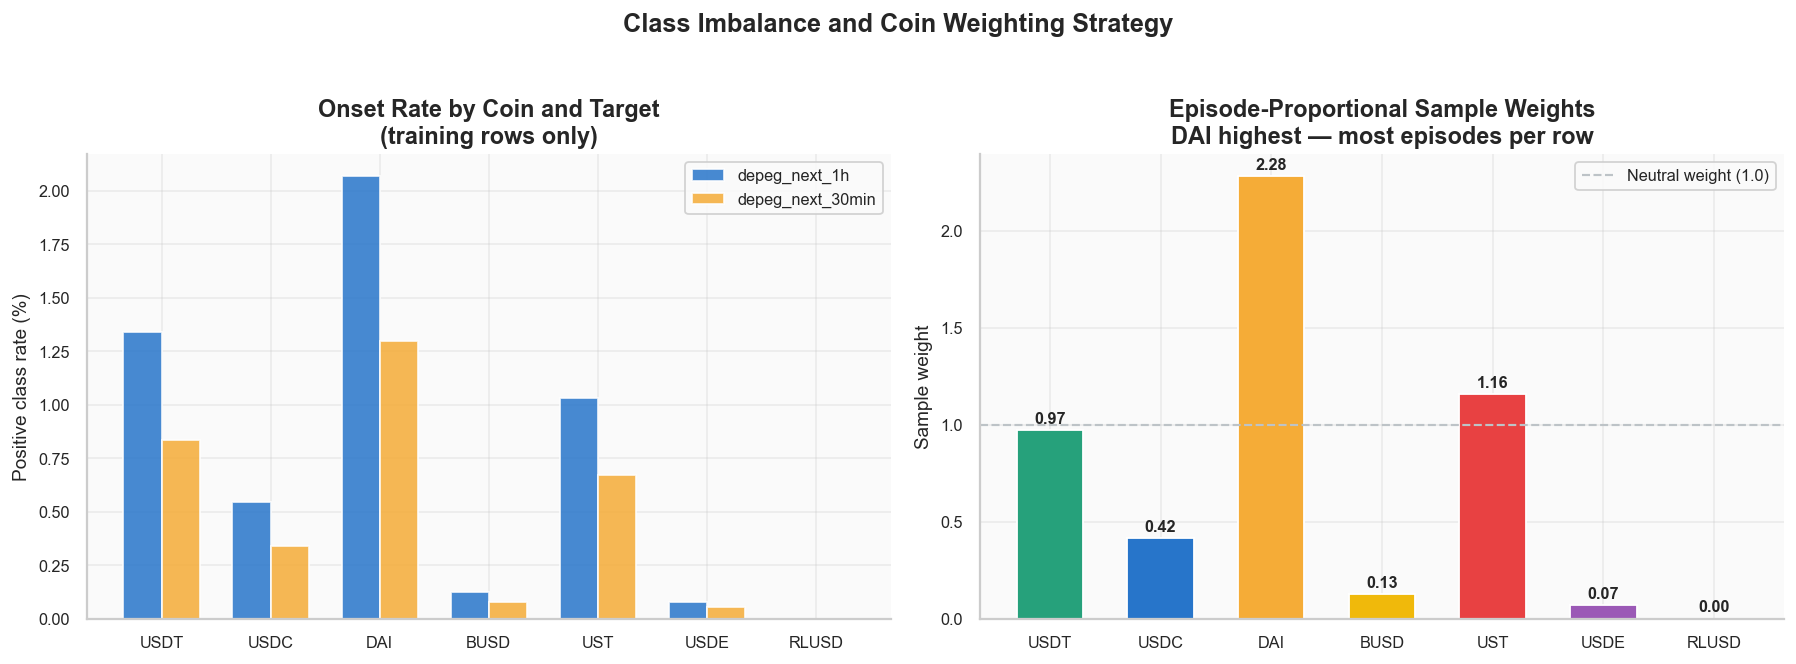

Completed in 0.6s


In [5]:
t0 = time.time()

onset_stats = []
for coin in COINS:
    sub = train[train['coin'] == coin]
    if len(sub) == 0:
        continue
    onset_stats.append({
        'coin':        coin.upper(),
        'stable':      len(sub),
        'pos_1h':      int(sub['depeg_next_1h'].sum()),
        'pos_30min':   int(sub['depeg_next_30min'].sum()),
        'rate_1h':     sub['depeg_next_1h'].mean() * 100,
        'rate_30min':  sub['depeg_next_30min'].mean() * 100,
        'weight':      COIN_WEIGHTS[coin],
    })

onset_df = pd.DataFrame(onset_stats).set_index('coin')
display(onset_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x     = np.arange(len(onset_df))
width = 0.35
axes[0].bar(x - width/2, onset_df['rate_1h'],
            width=width, color=ACCENT, alpha=0.85,
            edgecolor='white', label='depeg_next_1h')
axes[0].bar(x + width/2, onset_df['rate_30min'],
            width=width, color=ORANGE, alpha=0.85,
            edgecolor='white', label='depeg_next_30min')
axes[0].set_xticks(x)
axes[0].set_xticklabels(onset_df.index)
axes[0].set(ylabel='Positive class rate (%)', xlabel='',
            title='Onset Rate by Coin and Target\n(training rows only)')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

bars = axes[1].bar(
    onset_df.index, onset_df['weight'],
    color=[COIN_COLORS[c.lower()] for c in onset_df.index],
    edgecolor='white', width=0.6
)
for b, v in zip(bars, onset_df['weight']):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                 f'{v:.2f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
axes[1].axhline(1.0, color=LGRAY, lw=1.2, ls='--', label='Neutral weight (1.0)')
axes[1].set(ylabel='Sample weight', xlabel='',
            title='Episode-Proportional Sample Weights\n'
                  'DAI highest — most episodes per row')
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

fig.suptitle('Class Imbalance and Coin Weighting Strategy',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Completed in {time.time()-t0:.1f}s')

## 5. Helper Functions

In [6]:
def make_pool(data, target, cat_idx):
    '''
    Build a CatBoost Pool from a DataFrame slice.

    Parameters
    ----------
    data    : DataFrame with all_input columns and sample_weight column
    target  : str — column name of the binary target variable
    cat_idx : list[int] — integer indices of categorical columns in all_input

    Returns
    -------
    CatBoost Pool ready for fit() or eval_set
    '''
    X = data[all_input].copy()
    y = data[target].astype(int)
    w = data['sample_weight'].values
    return Pool(X, y, cat_features=cat_idx, weight=w, feature_names=all_input)


def f2_score(y_true, y_prob, threshold):
    '''
    F2 score at a given probability threshold.
    F2 weights recall twice as heavily as precision — missing a depeg is
    worse than a false alarm in a risk management context.
    '''
    y_pred    = (y_prob >= threshold).astype(int)
    tp        = int(((y_pred==1) & (y_true==1)).sum())
    fp        = int(((y_pred==1) & (y_true==0)).sum())
    fn        = int(((y_pred==0) & (y_true==1)).sum())
    precision = tp / (tp+fp) if (tp+fp) > 0 else 0.0
    recall    = tp / (tp+fn) if (tp+fn) > 0 else 0.0
    if precision + recall == 0:
        return 0.0
    return 5 * precision * recall / (4 * precision + recall)


def optimise_threshold(y_true, y_prob, steps=100):
    '''
    Sweep thresholds 0.05 to 0.50 and return the one maximising F2.
    Fit on validation set never on training data.

    Returns
    -------
    (best_threshold, best_f2) both rounded to 4 decimal places
    '''
    best_t, best_f2 = 0.5, 0.0
    for t in np.linspace(0.05, 0.50, steps):
        f2 = f2_score(y_true, y_prob, t)
        if f2 > best_f2:
            best_f2 = f2
            best_t  = t
    return round(best_t, 4), round(best_f2, 4)


def platt_calibrate(y_true, y_prob):
    '''
    Fit a Platt scaling logistic regression on validation probabilities.
    Fit on validation data only, fitting on training data would overfit.

    Returns
    -------
    Fitted LogisticRegression calibrator
    '''
    lr = LogisticRegression(C=1.0, solver='lbfgs')
    lr.fit(y_prob.reshape(-1, 1), y_true)
    return lr


def calibrate(calibrator, y_prob):
    '''Apply a fitted Platt calibrator. Returns calibrated probability array.'''
    return calibrator.predict_proba(y_prob.reshape(-1, 1))[:, 1]


def evaluate(y_true, y_prob_cal, threshold, label=''):
    '''
    Full evaluation metric suite on calibrated probabilities.
    Prints a formatted line if label is provided.

    Returns
    -------
    dict with keys: ap, auc, f2, precision, recall, tp, fp, fn
    '''
    y_pred = (y_prob_cal >= threshold).astype(int)
    ap     = average_precision_score(y_true, y_prob_cal)
    auc    = roc_auc_score(y_true, y_prob_cal)
    f2     = f2_score(y_true, y_prob_cal, threshold)
    tp     = int(((y_pred==1) & (y_true==1)).sum())
    fp     = int(((y_pred==1) & (y_true==0)).sum())
    fn     = int(((y_pred==0) & (y_true==1)).sum())
    prec   = tp / (tp+fp) if (tp+fp) > 0 else 0.0
    rec    = tp / (tp+fn) if (tp+fn) > 0 else 0.0

    if label:
        print(f'  {label}:  AUC-PR={ap:.4f}  AUC-ROC={auc:.4f}  '
              f'F2={f2:.4f}  Prec={prec:.3f}  Recall={rec:.3f}')
    return {'ap': ap, 'auc': auc, 'f2': f2,
            'precision': prec, 'recall': rec,
            'tp': tp, 'fp': fp, 'fn': fn}


# categorical feature index — same for both models
cat_idx = [all_input.index('u_coin_type')]

print('Helper functions defined.')

Helper functions defined.


## 6. Train Model 1 — depeg_next_1h

Precision model. A correctly fired alert gives up to 1 hour to act.

In [7]:
t0 = time.time()

TARGET_1H = 'depeg_next_1h'

train_pool_1h = make_pool(train, TARGET_1H, cat_idx)
val_pool_1h   = make_pool(val,   TARGET_1H, cat_idx)

model_1h = CatBoostClassifier(**BASE_CB_PARAMS)
model_1h.fit(
    train_pool_1h,
    eval_set       = val_pool_1h,
    use_best_model = True,
)

val_prob_1h_raw = model_1h.predict_proba(val[all_input])[:, 1]
calibrator_1h   = platt_calibrate(val[TARGET_1H].astype(int).values, val_prob_1h_raw)
val_prob_1h_cal = calibrate(calibrator_1h, val_prob_1h_raw)
threshold_1h, best_f2_1h = optimise_threshold(
    val[TARGET_1H].astype(int).values, val_prob_1h_cal
)

print(f'Model 1 (depeg_next_1h) training complete')
print(f'  Best iteration:  {model_1h.get_best_iteration()}')
print(f'  Val AUC-ROC:     {roc_auc_score(val[TARGET_1H], val_prob_1h_raw):.4f}')
print(f'  Val AUC-PR:      {average_precision_score(val[TARGET_1H], val_prob_1h_cal):.4f}')
print(f'  F2 threshold:    {threshold_1h}  (F2={best_f2_1h:.4f})')
print(f'\nCompleted in {time.time()-t0:.1f}s')

Model 1 (depeg_next_1h) training complete
  Best iteration:  33
  Val AUC-ROC:     0.9991
  Val AUC-PR:      0.4318
  F2 threshold:    0.05  (F2=0.5565)

Completed in 18.7s


## 7. Train Model 2 — depeg_next_30min

Short-horizon warning model. Fires earlier and tighter than Model 1.
When both models fire simultaneously the alert carries maximum confidence.
Replaces the previous depeg_next_4h model which suffered from near-zero
positive rate in the validation window (best iteration = 0, AUC-PR = 0.0003).
depeg_next_30min has a higher positive rate and a more actionable horizon.

In [8]:
t0 = time.time()

TARGET_2 = 'depeg_next_30min'

train_pool_2 = make_pool(train, TARGET_2, cat_idx)
val_pool_2   = make_pool(val,   TARGET_2, cat_idx)

model_2 = CatBoostClassifier(**BASE_CB_PARAMS)
model_2.fit(
    train_pool_2,
    eval_set       = val_pool_2,
    use_best_model = True,
)

val_prob_2_raw = model_2.predict_proba(val[all_input])[:, 1]
calibrator_2   = platt_calibrate(val[TARGET_2].astype(int).values, val_prob_2_raw)
val_prob_2_cal = calibrate(calibrator_2, val_prob_2_raw)
threshold_2, best_f2_2 = optimise_threshold(
    val[TARGET_2].astype(int).values, val_prob_2_cal
)

print(f'Model 2 (depeg_next_30min) training complete')
print(f'  Best iteration:  {model_2.get_best_iteration()}')
print(f'  Val AUC-ROC:     {roc_auc_score(val[TARGET_2], val_prob_2_raw):.4f}')
print(f'  Val AUC-PR:      {average_precision_score(val[TARGET_2], val_prob_2_cal):.4f}')
print(f'  F2 threshold:    {threshold_2}  (F2={best_f2_2:.4f})')
print(f'\nCompleted in {time.time()-t0:.1f}s')

Model 2 (depeg_next_30min) training complete
  Best iteration:  176
  Val AUC-ROC:     0.9999
  Val AUC-PR:      0.4957
  F2 threshold:    0.0864  (F2=0.6069)

Completed in 46.9s


## 8. Threshold Optimisation Visualisation

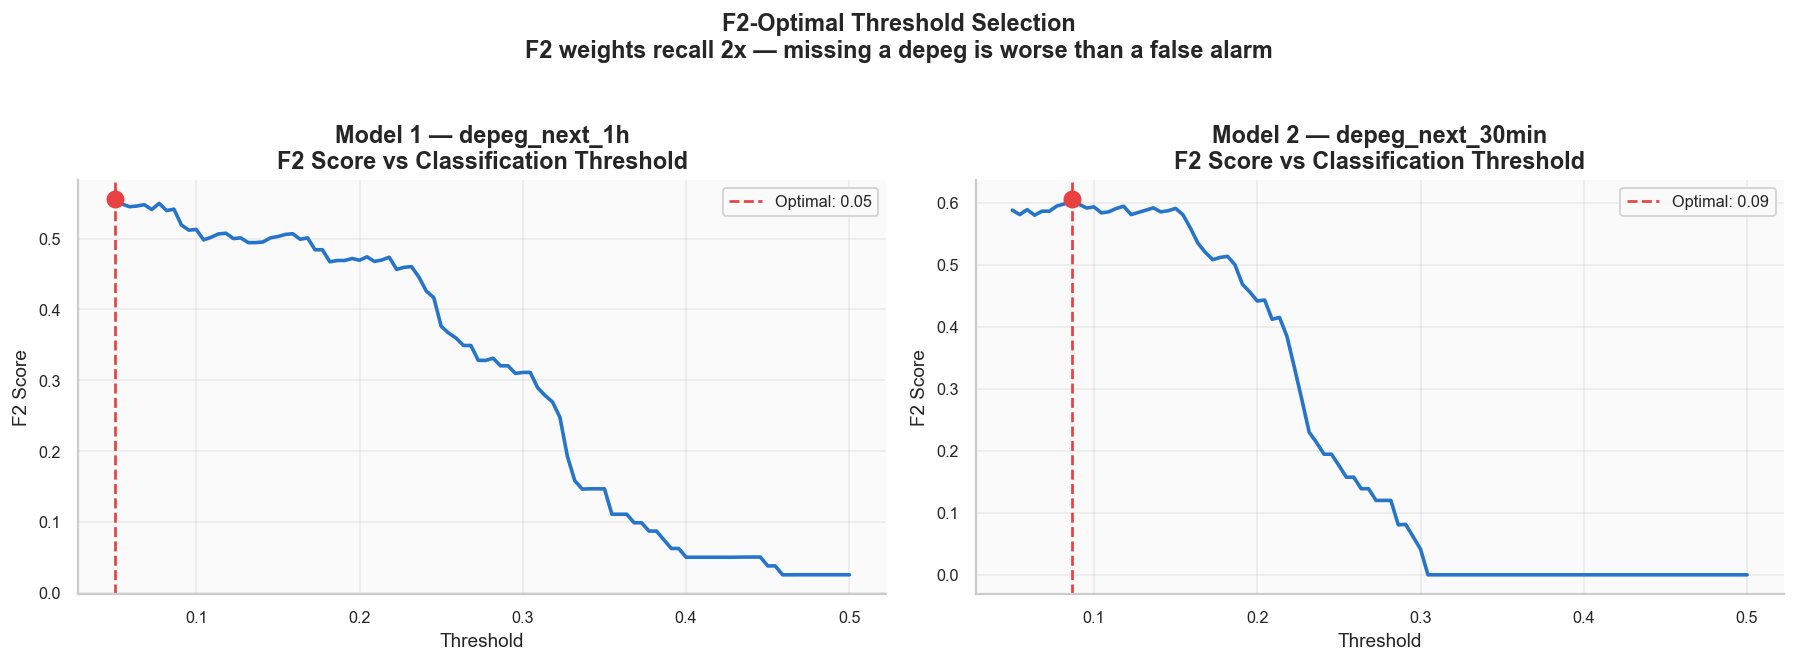

Completed in 0.3s


In [9]:
t0 = time.time()

thresholds = np.linspace(0.05, 0.50, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_true, y_prob, thresh, model_name) in zip(axes, [
    (val[TARGET_1H].astype(int).values,
     val_prob_1h_cal, threshold_1h, 'Model 1 — depeg_next_1h'),
    (val[TARGET_2].astype(int).values,
     val_prob_2_cal,  threshold_2,  'Model 2 — depeg_next_30min'),
]):
    f2_scores = [f2_score(y_true, y_prob, t) for t in thresholds]
    ax.plot(thresholds, f2_scores, color=ACCENT, lw=2)
    ax.axvline(thresh, color=RED, lw=1.5, ls='--',
               label=f'Optimal: {thresh:.2f}')
    ax.scatter([thresh], [f2_score(y_true, y_prob, thresh)],
               color=RED, s=80, zorder=5)
    ax.set(xlabel='Threshold', ylabel='F2 Score',
           title=f'{model_name}\nF2 Score vs Classification Threshold')
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

fig.suptitle('F2-Optimal Threshold Selection\n'
             'F2 weights recall 2x — missing a depeg is worse than a false alarm',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Completed in {time.time()-t0:.1f}s')

## 9. Precision-Recall Curves

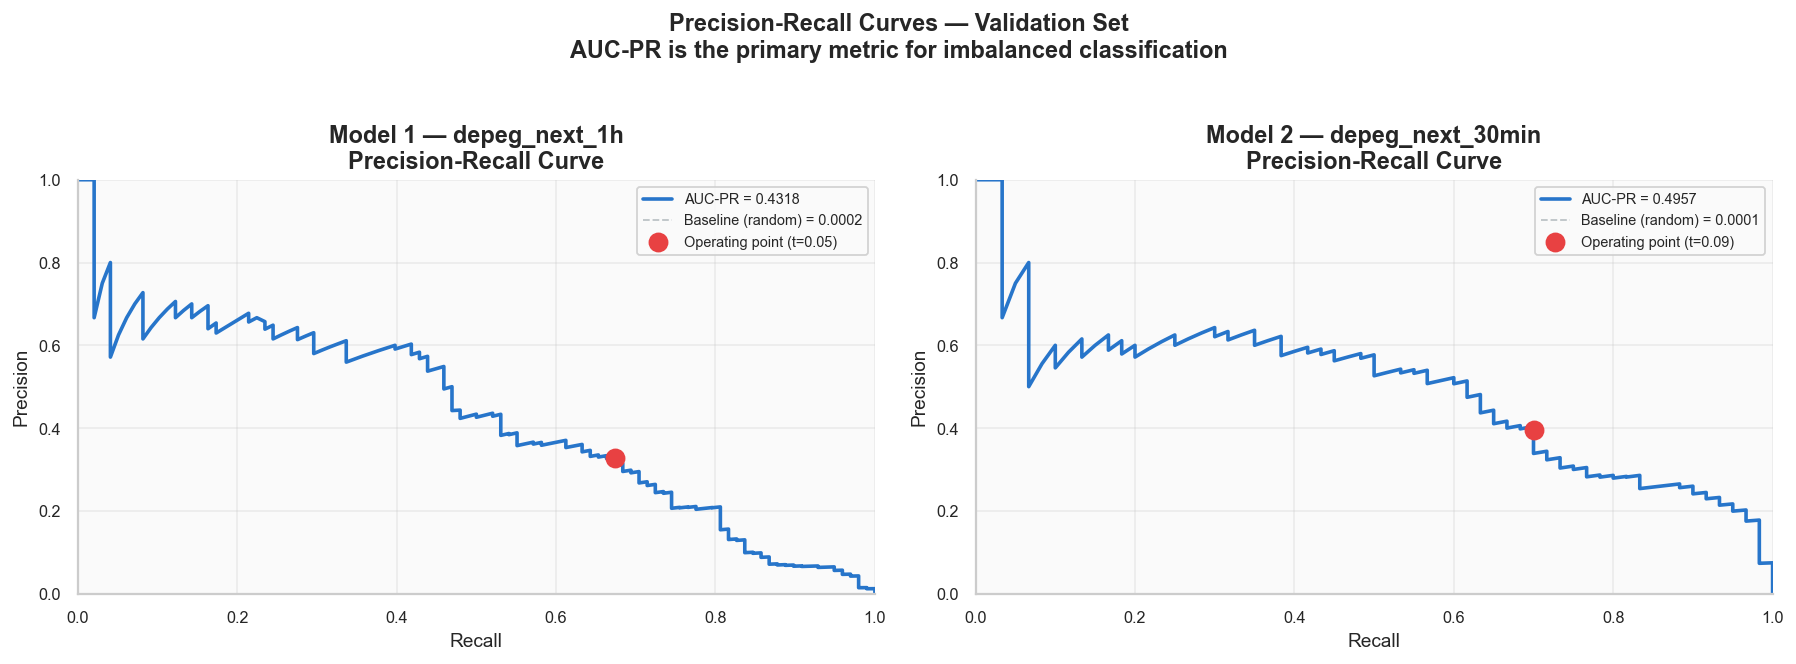

Completed in 0.5s


In [10]:
t0 = time.time()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (target, y_true, y_prob, thresh, model_name) in zip(axes, [
    (TARGET_1H, val[TARGET_1H].astype(int).values,
     val_prob_1h_cal, threshold_1h, 'Model 1 — depeg_next_1h'),
    (TARGET_2,  val[TARGET_2].astype(int).values,
     val_prob_2_cal,  threshold_2,  'Model 2 — depeg_next_30min'),
]):
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap           = average_precision_score(y_true, y_prob)

    ax.plot(rec, prec, color=ACCENT, lw=2, label=f'AUC-PR = {ap:.4f}')
    ax.axhline(y_true.mean(), color=LGRAY, lw=1, ls='--',
               label=f'Baseline (random) = {y_true.mean():.4f}')

    op_pred = (y_prob >= thresh).astype(int)
    tp      = int(((op_pred==1) & (y_true==1)).sum())
    fp      = int(((op_pred==1) & (y_true==0)).sum())
    fn      = int(((op_pred==0) & (y_true==1)).sum())
    p_op    = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    r_op    = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    ax.scatter([r_op], [p_op], color=RED, s=100, zorder=5,
               label=f'Operating point (t={thresh:.2f})')

    ax.set(xlabel='Recall', ylabel='Precision', xlim=[0,1], ylim=[0,1],
           title=f'{model_name}\nPrecision-Recall Curve')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

fig.suptitle('Precision-Recall Curves — Validation Set\n'
             'AUC-PR is the primary metric for imbalanced classification',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Completed in {time.time()-t0:.1f}s')

## 10. LOEO Cross-Validation

Leave-One-Event-Out: remove each known crisis from training, retrain,
evaluate on the held-out crisis. Tests generalisation to unseen crises.
Five events with confirmed depeg bars used (BUSD/FTX and USDE excluded).

**Lead time** — hours before the first depeg bar that the model first fired
is the primary LOEO metric. Target: > 2 hours.

In [11]:
t0 = time.time()

# free RAM before the memory intensived loop
# remove training pools and selection objects no longer needed
for obj_name in ['train_pool_1h', 'val_pool_1h', 'train_pool_2', 'val_pool_2']:
    if obj_name in dir():
        exec(f'del {obj_name}')
gc.collect()
print(f'RAM before LOEO: {ram_used_gb():.1f} GB\n')

loeo_results = []

for coin, event_name, start, end in LOEO_EVENTS:
    print(f'\n--- LOEO: {event_name} ---')
    print(f'  RAM: {ram_used_gb():.1f} GB')
    t_event = time.time()

    event_start = pd.Timestamp(start, tz='UTC')
    event_end   = pd.Timestamp(end,   tz='UTC')

    # exclude event window + buffer from LOEO training
    # uses the full df (all coins, both splits) to maximise training data per fold
    exclude_mask = (
        (df.index >= event_start - LOEO_BUFFER) &
        (df.index <= event_end   + LOEO_BUFFER)
    )
    loeo_train = df[~exclude_mask].copy()
    loeo_event = df[exclude_mask & (df['coin'] == coin)].copy()

    if len(loeo_event) == 0 or loeo_event[TARGET_1H].sum() == 0:
        print(f'  Skipping — no depeg_next_1h rows in window for {coin.upper()}')
        continue

    print(f'  Training rows: {len(loeo_train):,}  |  '
          f'Event rows: {len(loeo_event):,}  |  '
          f'Depeg bars (1h): {int(loeo_event[TARGET_1H].sum())}')

    # inner 85/15 chronological split for early stopping
    loeo_n         = len(loeo_train)
    loeo_inner_end = int(loeo_n * 0.85)
    loeo_inner_tr  = loeo_train.iloc[:loeo_inner_end]
    loeo_inner_val = loeo_train.iloc[loeo_inner_end:]

    loeo_tr_pool_1h  = make_pool(loeo_inner_tr,  TARGET_1H, cat_idx)
    loeo_val_pool_1h = make_pool(loeo_inner_val, TARGET_1H, cat_idx)
    loeo_tr_pool_2   = make_pool(loeo_inner_tr,  TARGET_2,  cat_idx)
    loeo_val_pool_2  = make_pool(loeo_inner_val, TARGET_2,  cat_idx)

    loeo_model_1h = CatBoostClassifier(**LOEO_PARAMS)
    loeo_model_2  = CatBoostClassifier(**LOEO_PARAMS)
    loeo_model_1h.fit(loeo_tr_pool_1h, eval_set=loeo_val_pool_1h,
                      use_best_model=True)
    loeo_model_2.fit(loeo_tr_pool_2,   eval_set=loeo_val_pool_2,
                     use_best_model=True)

    # predict on event window — use global calibrators (fitted on full val set)
    event_prob_1h_raw = loeo_model_1h.predict_proba(loeo_event[all_input])[:, 1]
    event_prob_2_raw  = loeo_model_2.predict_proba(loeo_event[all_input])[:, 1]
    event_prob_1h     = calibrate(calibrator_1h, event_prob_1h_raw)
    event_prob_2      = calibrate(calibrator_2,  event_prob_2_raw)

    y_event_1h = loeo_event[TARGET_1H].astype(int).values
    y_event_2  = loeo_event[TARGET_2].astype(int).values

    # metrics
    ap_1h  = average_precision_score(y_event_1h, event_prob_1h) if y_event_1h.sum() > 0 else np.nan
    ap_2   = average_precision_score(y_event_2,  event_prob_2)  if y_event_2.sum()  > 0 else np.nan
    f2_1h  = f2_score(y_event_1h, event_prob_1h, threshold_1h)
    f2_2   = f2_score(y_event_2,  event_prob_2,  threshold_2)

    # lead time — hours before first depeg that the model first fired
    first_depeg_idx  = loeo_event.index[y_event_1h == 1]
    alert_idx_1h     = loeo_event.index[event_prob_1h >= threshold_1h]
    alert_idx_2      = loeo_event.index[event_prob_2  >= threshold_2]

    lead_1h = 0.0
    if len(first_depeg_idx) > 0 and len(alert_idx_1h) > 0:
        first_depeg     = first_depeg_idx[0]
        early_alerts_1h = alert_idx_1h[alert_idx_1h < first_depeg]
        if len(early_alerts_1h) > 0:
            lead_1h = (first_depeg - early_alerts_1h[0]).total_seconds() / 3600

    lead_2 = 0.0
    if len(first_depeg_idx) > 0 and len(alert_idx_2) > 0:
        first_depeg   = first_depeg_idx[0]
        early_alerts_2 = alert_idx_2[alert_idx_2 < first_depeg]
        if len(early_alerts_2) > 0:
            lead_2 = (first_depeg - early_alerts_2[0]).total_seconds() / 3600

    loeo_results.append({
        'event':        event_name,
        'coin':         coin.upper(),
        'ap_1h':        round(ap_1h,  4),
        'ap_30min':     round(ap_2,   4),
        'f2_1h':        round(f2_1h,  4),
        'f2_30min':     round(f2_2,   4),
        'lead_1h_h':    round(lead_1h, 2),
        'lead_30min_h': round(lead_2,  2),
    })

    print(f'  AUC-PR 1h={ap_1h:.4f}  30min={ap_2:.4f}  |  '
          f'Lead 1h={lead_1h:.1f}h  30min={lead_2:.1f}h  |  '
          f'took {time.time()-t_event:.0f}s')

    # free fold memory immediately — critical to prevent OOM across 5 folds
    del (loeo_model_1h, loeo_model_2,
         loeo_tr_pool_1h, loeo_val_pool_1h,
         loeo_tr_pool_2, loeo_val_pool_2)
    gc.collect()
    print(f'  RAM after cleanup: {ram_used_gb():.1f} GB')

loeo_df = pd.DataFrame(loeo_results).set_index('event')
print(f'\nLOEO completed in {time.time()-t0:.1f}s')
display(loeo_df)

RAM before LOEO: 12.1 GB


--- LOEO: Oct 2018 USDT Reserve Scare ---
  RAM: 12.1 GB
  Training rows: 3,096,831  |  Event rows: 15  |  Depeg bars (1h): 15
  AUC-PR 1h=1.0000  30min=0.8507  |  Lead 1h=0.0h  30min=0.0h  |  took 68s
  RAM after cleanup: 11.2 GB

--- LOEO: Mar 2020 Black Thursday ---
  RAM: 11.2 GB
  Training rows: 3,092,194  |  Event rows: 966  |  Depeg bars (1h): 96
  AUC-PR 1h=0.6002  30min=0.5619  |  Lead 1h=1.2h  30min=1.1h  |  took 57s
  RAM after cleanup: 9.8 GB

--- LOEO: May 2022 UST Collapse ---
  RAM: 9.8 GB
  Training rows: 3,087,489  |  Event rows: 1,408  |  Depeg bars (1h): 71
  AUC-PR 1h=0.3198  30min=0.2861  |  Lead 1h=0.0h  30min=0.0h  |  took 44s
  RAM after cleanup: 10.6 GB

--- LOEO: May 2022 UST Contagion ---
  RAM: 10.6 GB
  Training rows: 3,085,185  |  Event rows: 3,716  |  Depeg bars (1h): 12
  AUC-PR 1h=0.1246  30min=0.2071  |  Lead 1h=15.9h  30min=15.9h  |  took 57s
  RAM after cleanup: 10.4 GB

--- LOEO: Mar 2023 SVB Bank Run ---
  RAM: 10.4 GB
  

,coin,ap_1h,ap_30min,f2_1h,f2_30min,lead_1h_h,lead_30min_h
event,,,,,,,
Oct 2018 USDT Reserve Scare,USDT,1.0000,0.8507,1.0000,0.9524,0.00,0.00
Mar 2020 Black Thursday,DAI,0.6002,0.5619,0.6769,0.6754,1.17,1.08
May 2022 UST Collapse,UST,0.3198,0.2861,0.6587,0.4075,0.00,0.00
May 2022 UST Contagion,USDC,0.1246,0.2071,0.1531,0.2041,15.92,15.92
Mar 2023 SVB Bank Run,USDC,0.6192,0.7101,0.0000,0.6569,0.00,0.00


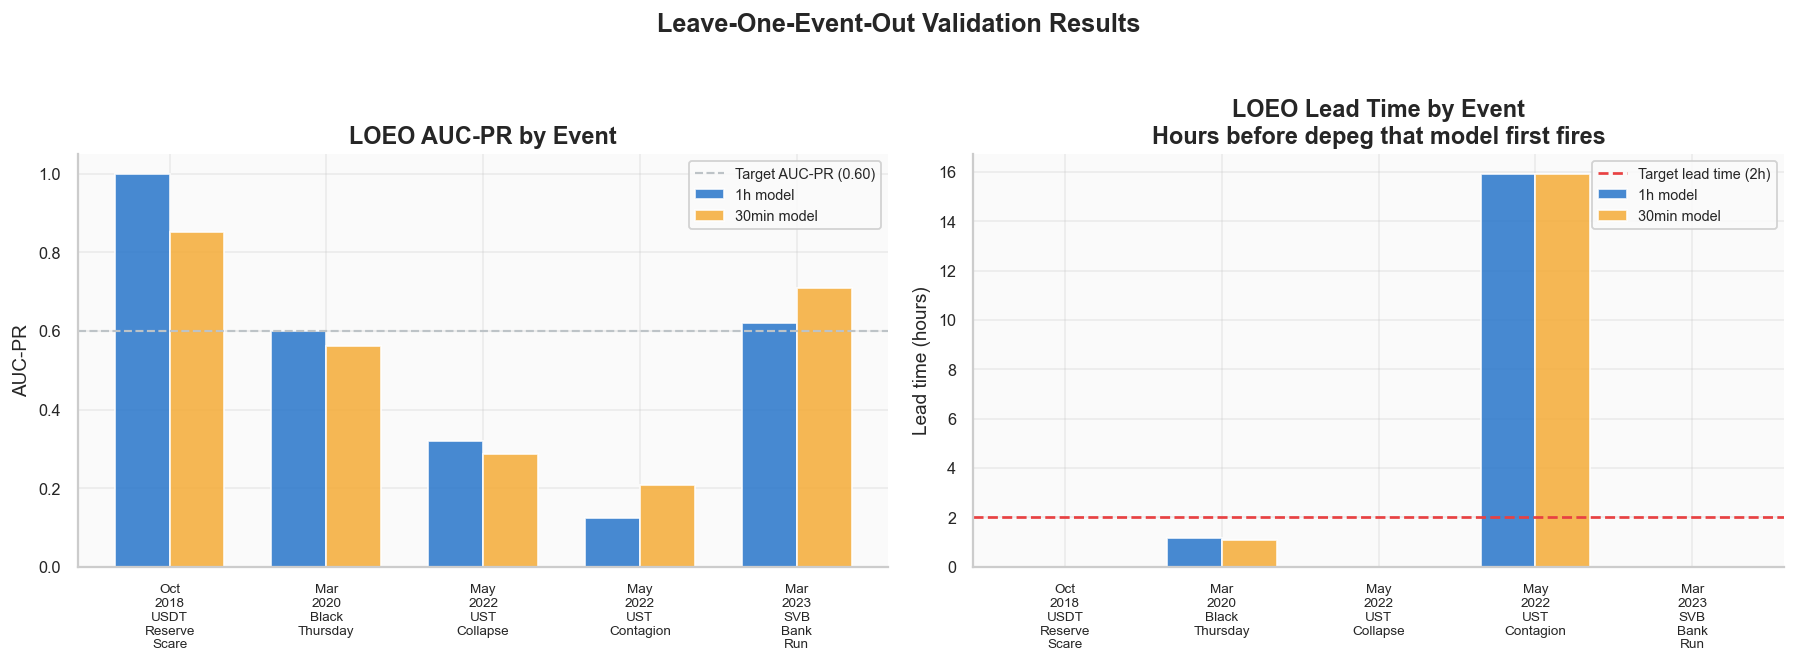

Completed in 0.1s


In [12]:
t0 = time.time()

if len(loeo_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x     = np.arange(len(loeo_df))
    width = 0.35

    axes[0].bar(x-width/2, loeo_df['ap_1h'],    width=width,
                color=ACCENT, alpha=0.85, edgecolor='white', label='1h model')
    axes[0].bar(x+width/2, loeo_df['ap_30min'], width=width,
                color=ORANGE, alpha=0.85, edgecolor='white', label='30min model')
    axes[0].axhline(0.60, color=LGRAY, lw=1.2, ls='--', label='Target AUC-PR (0.60)')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([e.replace(' ', '\n') for e in loeo_df.index], fontsize=7.5)
    axes[0].set(ylabel='AUC-PR', title='LOEO AUC-PR by Event')
    axes[0].legend(fontsize=8)
    sns.despine(ax=axes[0])

    axes[1].bar(x-width/2, loeo_df['lead_1h_h'],    width=width,
                color=ACCENT, alpha=0.85, edgecolor='white', label='1h model')
    axes[1].bar(x+width/2, loeo_df['lead_30min_h'], width=width,
                color=ORANGE, alpha=0.85, edgecolor='white', label='30min model')
    axes[1].axhline(2.0, color=RED, lw=1.5, ls='--', label='Target lead time (2h)')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([e.replace(' ', '\n') for e in loeo_df.index], fontsize=7.5)
    axes[1].set(ylabel='Lead time (hours)',
                title='LOEO Lead Time by Event\nHours before depeg that model first fires')
    axes[1].legend(fontsize=8)
    sns.despine(ax=axes[1])

    fig.suptitle('Leave-One-Event-Out Validation Results',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print(f'Completed in {time.time()-t0:.1f}s')

## 11. Isolation Forest (Unsupervised Detector)

Trained only on confirmed normal rows where the coin is stable now AND
will remain stable for 30 minutes (`depeg_next_1h==0 AND depeg_next_30min==0`).
Uses only universal numeric features. Supplementary NaNs would distort
anomaly scores since IsolationForest treats NaN as a feature value.

In [13]:
t0 = time.time()

# genuinely normal rows — stable now and for the next 30 minutes
normal_mask = (df['depeg_next_1h'] == 0) & (df['depeg_next_30min'] == 0)

# exclude features that are entirely NaN across normal rows —
# u_volume_surge_6h and u_volume_z_score_7d have no valid values
# in the pooled dataset so they would wipe out X_normal via dropna
u_feats = [
    c for c in feat_cols
    if c.startswith('u_')
    and c != 'u_coin_type'
    and df.loc[normal_mask, c].notna().any()   # drop if entirely NaN
]

print(f'Universal features for IF: {len(u_feats)}')

# fill remaining sparse NaNs with per-feature median rather than
# dropping rows — consistent with how we score the full dataset below
X_normal = df.loc[normal_mask, u_feats].fillna(df[u_feats].median())

print(f'Normal rows for Isolation Forest: {len(X_normal):,}  '
      f'({len(X_normal)/len(df)*100:.1f}% of dataset)')

iso_forest = IsolationForest(
    n_estimators  = 200,
    contamination = 0.02,
    random_state  = 42,
    n_jobs        = -1,
)
iso_forest.fit(X_normal)

# score full dataset — fill NaNs with median before scoring
raw_scores = iso_forest.decision_function(
    df[u_feats].fillna(df[u_feats].median())
)
df['anomaly_score'] = (
    100 * (1 - (raw_scores - raw_scores.min()) /
           (raw_scores.max() - raw_scores.min()))
)
df['anomaly_flag'] = (df['anomaly_score'] >= 80).astype(int)

print(f'Anomaly flag rate: {df["anomaly_flag"].mean():.2%}')
print(f'\nIsolation Forest completed in {time.time()-t0:.1f}s')

Universal features for IF: 13
Normal rows for Isolation Forest: 3,078,242  (99.3% of dataset)
Anomaly flag rate: 0.18%

Isolation Forest completed in 16.2s


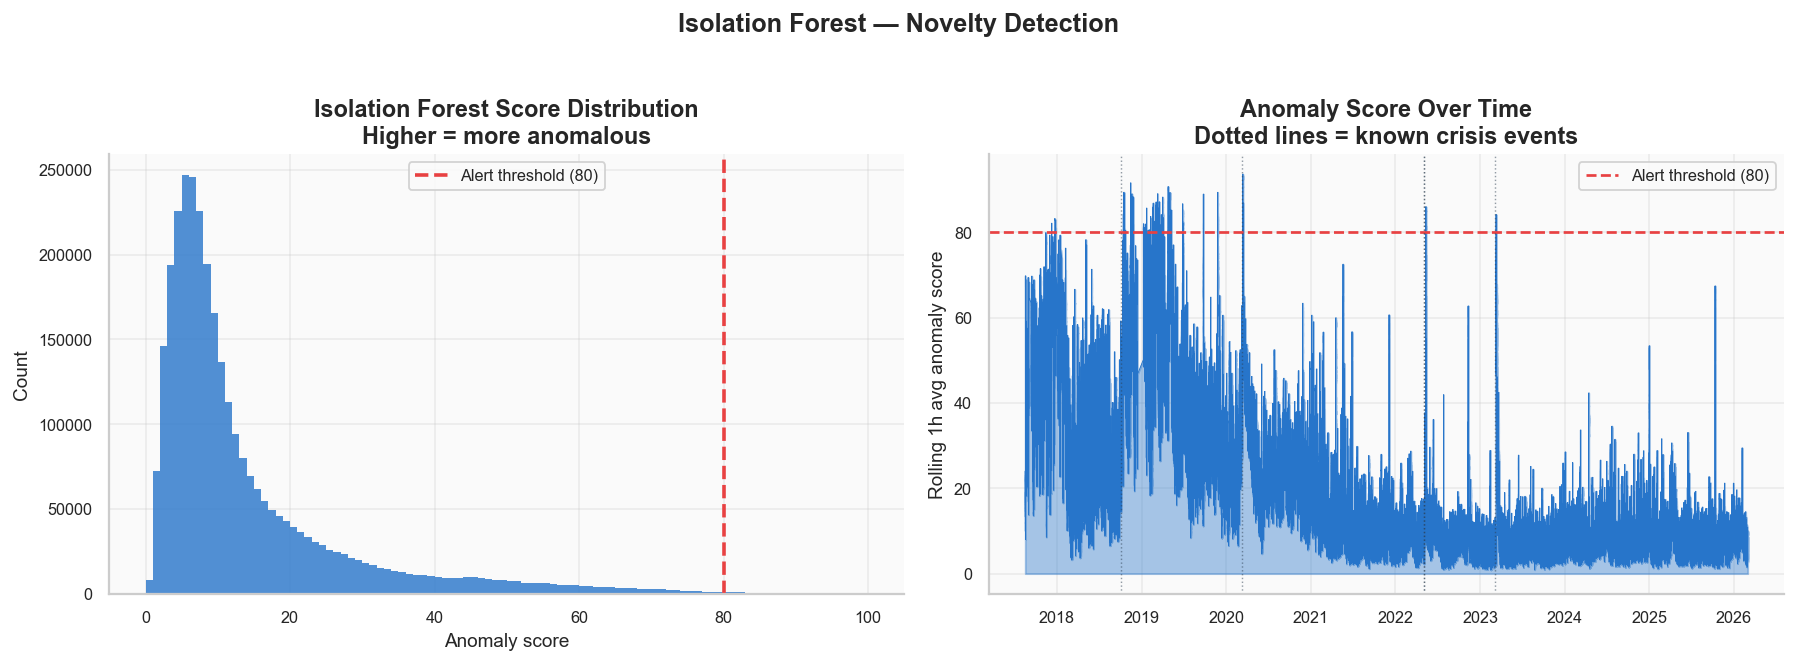

Completed in 25.9s


In [14]:
t0 = time.time()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['anomaly_score'], bins=100,
             color=ACCENT, edgecolor='none', alpha=0.8)
axes[0].axvline(80, color=RED, lw=2, ls='--', label='Alert threshold (80)')
axes[0].set(xlabel='Anomaly score', ylabel='Count',
            title='Isolation Forest Score Distribution\nHigher = more anomalous')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

roll_anom = df['anomaly_score'].rolling(BARS_1H, min_periods=1).mean()
axes[1].fill_between(df.index, roll_anom, alpha=0.4, color=ACCENT)
axes[1].plot(df.index, roll_anom, lw=0.5, color=ACCENT)
axes[1].axhline(80, color=RED, lw=1.5, ls='--', label='Alert threshold (80)')
for _, event_name, start, _ in LOEO_EVENTS:
    axes[1].axvline(pd.Timestamp(start, tz='UTC'), color=DARK, lw=0.8, ls=':', alpha=0.5)
axes[1].set(ylabel='Rolling 1h avg anomaly score',
            title='Anomaly Score Over Time\nDotted lines = known crisis events')
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

fig.suptitle('Isolation Forest — Novelty Detection',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Completed in {time.time()-t0:.1f}s')

## 12. Final Evaluation on Test Set

The test set is touched here for the first and only time.

In [15]:
t0 = time.time()

test_prob_1h_raw = model_1h.predict_proba(test[all_input])[:, 1]
test_prob_2_raw  = model_2.predict_proba(test[all_input])[:, 1]
test_prob_1h_cal = calibrate(calibrator_1h, test_prob_1h_raw)
test_prob_2_cal  = calibrate(calibrator_2,  test_prob_2_raw)

print('=== FINAL TEST SET EVALUATION ===\n')
print('Model 1 — depeg_next_1h:')
overall_1h = evaluate(test[TARGET_1H].astype(int).values,
                      test_prob_1h_cal, threshold_1h, 'Overall')
print()
print('Model 2 — depeg_next_30min:')
overall_2  = evaluate(test[TARGET_2].astype(int).values,
                      test_prob_2_cal, threshold_2, 'Overall')

print(f'\nTest evaluation completed in {time.time()-t0:.1f}s')

=== FINAL TEST SET EVALUATION ===

Model 1 — depeg_next_1h:
  Overall:  AUC-PR=0.3174  AUC-ROC=0.9979  F2=0.5355  Prec=0.233  Recall=0.792

Model 2 — depeg_next_30min:
  Overall:  AUC-PR=0.4139  AUC-ROC=0.9993  F2=0.4816  Prec=0.399  Recall=0.508

Test evaluation completed in 0.4s


In [16]:
t0 = time.time()

print('=== PER-COIN TEST SET EVALUATION ===\n')
coin_metrics = []

for coin in COINS:
    # get positional indices of this coin's rows in the test array
    # this guarantees p1h and y1h are always the same length
    pos_idx = np.where(test['coin'].values == coin)[0]

    if len(pos_idx) == 0:
        print(f'{coin.upper():6s}: no rows in test set — skipping')
        continue

    p1h = test_prob_1h_cal[pos_idx]
    p2  = test_prob_2_cal[pos_idx]
    y1h = test[TARGET_1H].astype(int).values[pos_idx]
    y2  = test[TARGET_2].astype(int).values[pos_idx]

    if y1h.sum() == 0:
        print(f'{coin.upper():6s}: no positive rows — skipping')
        continue

    ap1h = average_precision_score(y1h, p1h)
    ap2  = average_precision_score(y2,  p2) if y2.sum() > 0 else np.nan
    f21h = f2_score(y1h, p1h, threshold_1h)
    f22  = f2_score(y2,  p2,  threshold_2)

    coin_metrics.append({
        'Coin':      coin.upper(),
        'AP 1h':     round(ap1h, 4),
        'AP 30min':  round(ap2,  4),
        'F2 1h':     round(f21h, 4),
        'F2 30min':  round(f22,  4),
        'Pos 1h':    int(y1h.sum()),
        'Rows':      len(pos_idx),
    })
    print(f'{coin.upper():6s}: AP_1h={ap1h:.4f}  AP_30min={ap2:.4f}  '
          f'F2_1h={f21h:.4f}  F2_30min={f22:.4f}  '
          f'(pos={int(y1h.sum())}, n={len(pos_idx):,})')

coin_metrics_df = pd.DataFrame(coin_metrics).set_index('Coin')
display(coin_metrics_df)
print(f'\nPer-coin evaluation completed in {time.time()-t0:.1f}s')

=== PER-COIN TEST SET EVALUATION ===

USDT  : AP_1h=0.5282  AP_30min=0.5785  F2_1h=0.3636  F2_30min=0.4839  (pos=12, n=122,411)
USDC  : no positive rows — skipping
DAI   : no positive rows — skipping
BUSD  : AP_1h=0.4113  AP_30min=0.5363  F2_1h=0.5711  F2_30min=0.6920  (pos=77, n=55,474)
UST   : AP_1h=0.3247  AP_30min=0.3506  F2_1h=0.5338  F2_30min=0.4212  (pos=324, n=21,869)
USDE  : no positive rows — skipping
RLUSD : no positive rows — skipping


,AP 1h,AP 30min,F2 1h,F2 30min,Pos 1h,Rows
Coin,,,,,,
USDT,0.5282,0.5785,0.3636,0.4839,12,122411
BUSD,0.4113,0.5363,0.5711,0.6920,77,55474
UST,0.3247,0.3506,0.5338,0.4212,324,21869



Per-coin evaluation completed in 0.1s


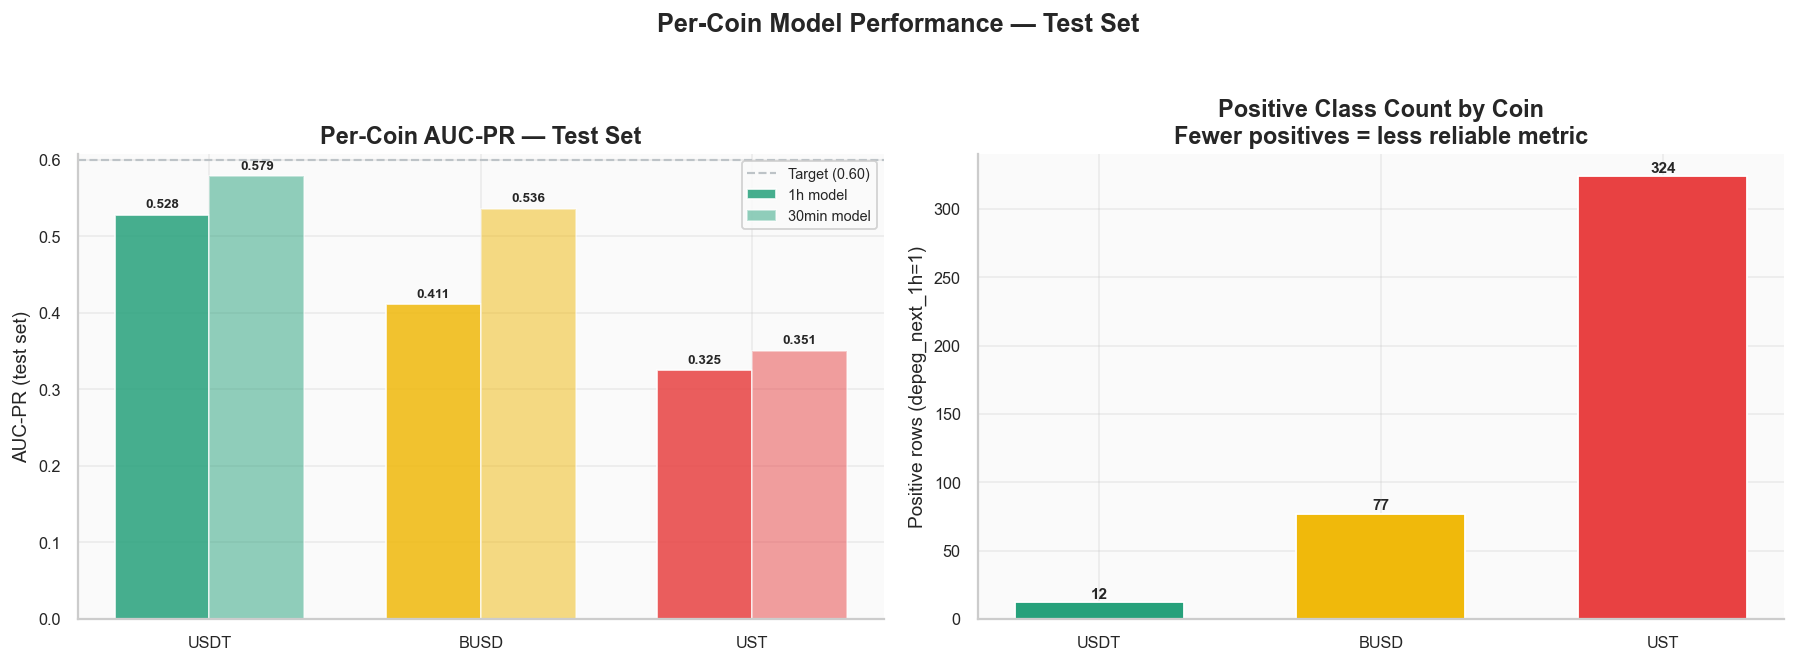

Completed in 0.1s


In [17]:
t0 = time.time()

if len(coin_metrics_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x     = np.arange(len(coin_metrics_df))
    width = 0.35

    axes[0].bar(x-width/2, coin_metrics_df['AP 1h'], width=width,
                color=[COIN_COLORS[c.lower()] for c in coin_metrics_df.index],
                alpha=0.85, edgecolor='white', label='1h model')
    axes[0].bar(x+width/2, coin_metrics_df['AP 30min'], width=width,
                color=[COIN_COLORS[c.lower()] for c in coin_metrics_df.index],
                alpha=0.5, edgecolor='white', label='30min model')
    for i, (ap1, ap2) in enumerate(zip(coin_metrics_df['AP 1h'],
                                        coin_metrics_df['AP 30min'])):
        axes[0].text(i-width/2, ap1+0.005, f'{ap1:.3f}',
                     ha='center', va='bottom', fontsize=7.5, fontweight='bold')
        axes[0].text(i+width/2, ap2+0.005, f'{ap2:.3f}',
                     ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    axes[0].axhline(0.60, color=LGRAY, lw=1.2, ls='--', label='Target (0.60)')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(coin_metrics_df.index)
    axes[0].set(ylabel='AUC-PR (test set)',
                title='Per-Coin AUC-PR — Test Set')
    axes[0].legend(fontsize=8)
    sns.despine(ax=axes[0])

    bars = axes[1].bar(
        coin_metrics_df.index, coin_metrics_df['Pos 1h'],
        color=[COIN_COLORS[c.lower()] for c in coin_metrics_df.index],
        edgecolor='white', width=0.6
    )
    for b in bars:
        axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                     f'{int(b.get_height()):,}',
                     ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    axes[1].set(ylabel='Positive rows (depeg_next_1h=1)',
                title='Positive Class Count by Coin\nFewer positives = less reliable metric')
    sns.despine(ax=axes[1])

    fig.suptitle('Per-Coin Model Performance — Test Set',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print(f'Completed in {time.time()-t0:.1f}s')

## 13. SHAP Feature Importance

In [18]:
t0 = time.time()

sample_size  = min(5000, len(test))
test_sample  = test.sample(n=sample_size, random_state=42)
X_sample     = test_sample[all_input]

explainer_1h = shap.TreeExplainer(model_1h)
shap_vals_1h = explainer_1h.shap_values(X_sample)

print(f'SHAP computed on {sample_size:,} test rows')
print(f'Completed in {time.time()-t0:.1f}s')

SHAP computed on 5,000 test rows
Completed in 0.1s


SHAP computed on 5,000 test rows for both models
Completed in 0.2s


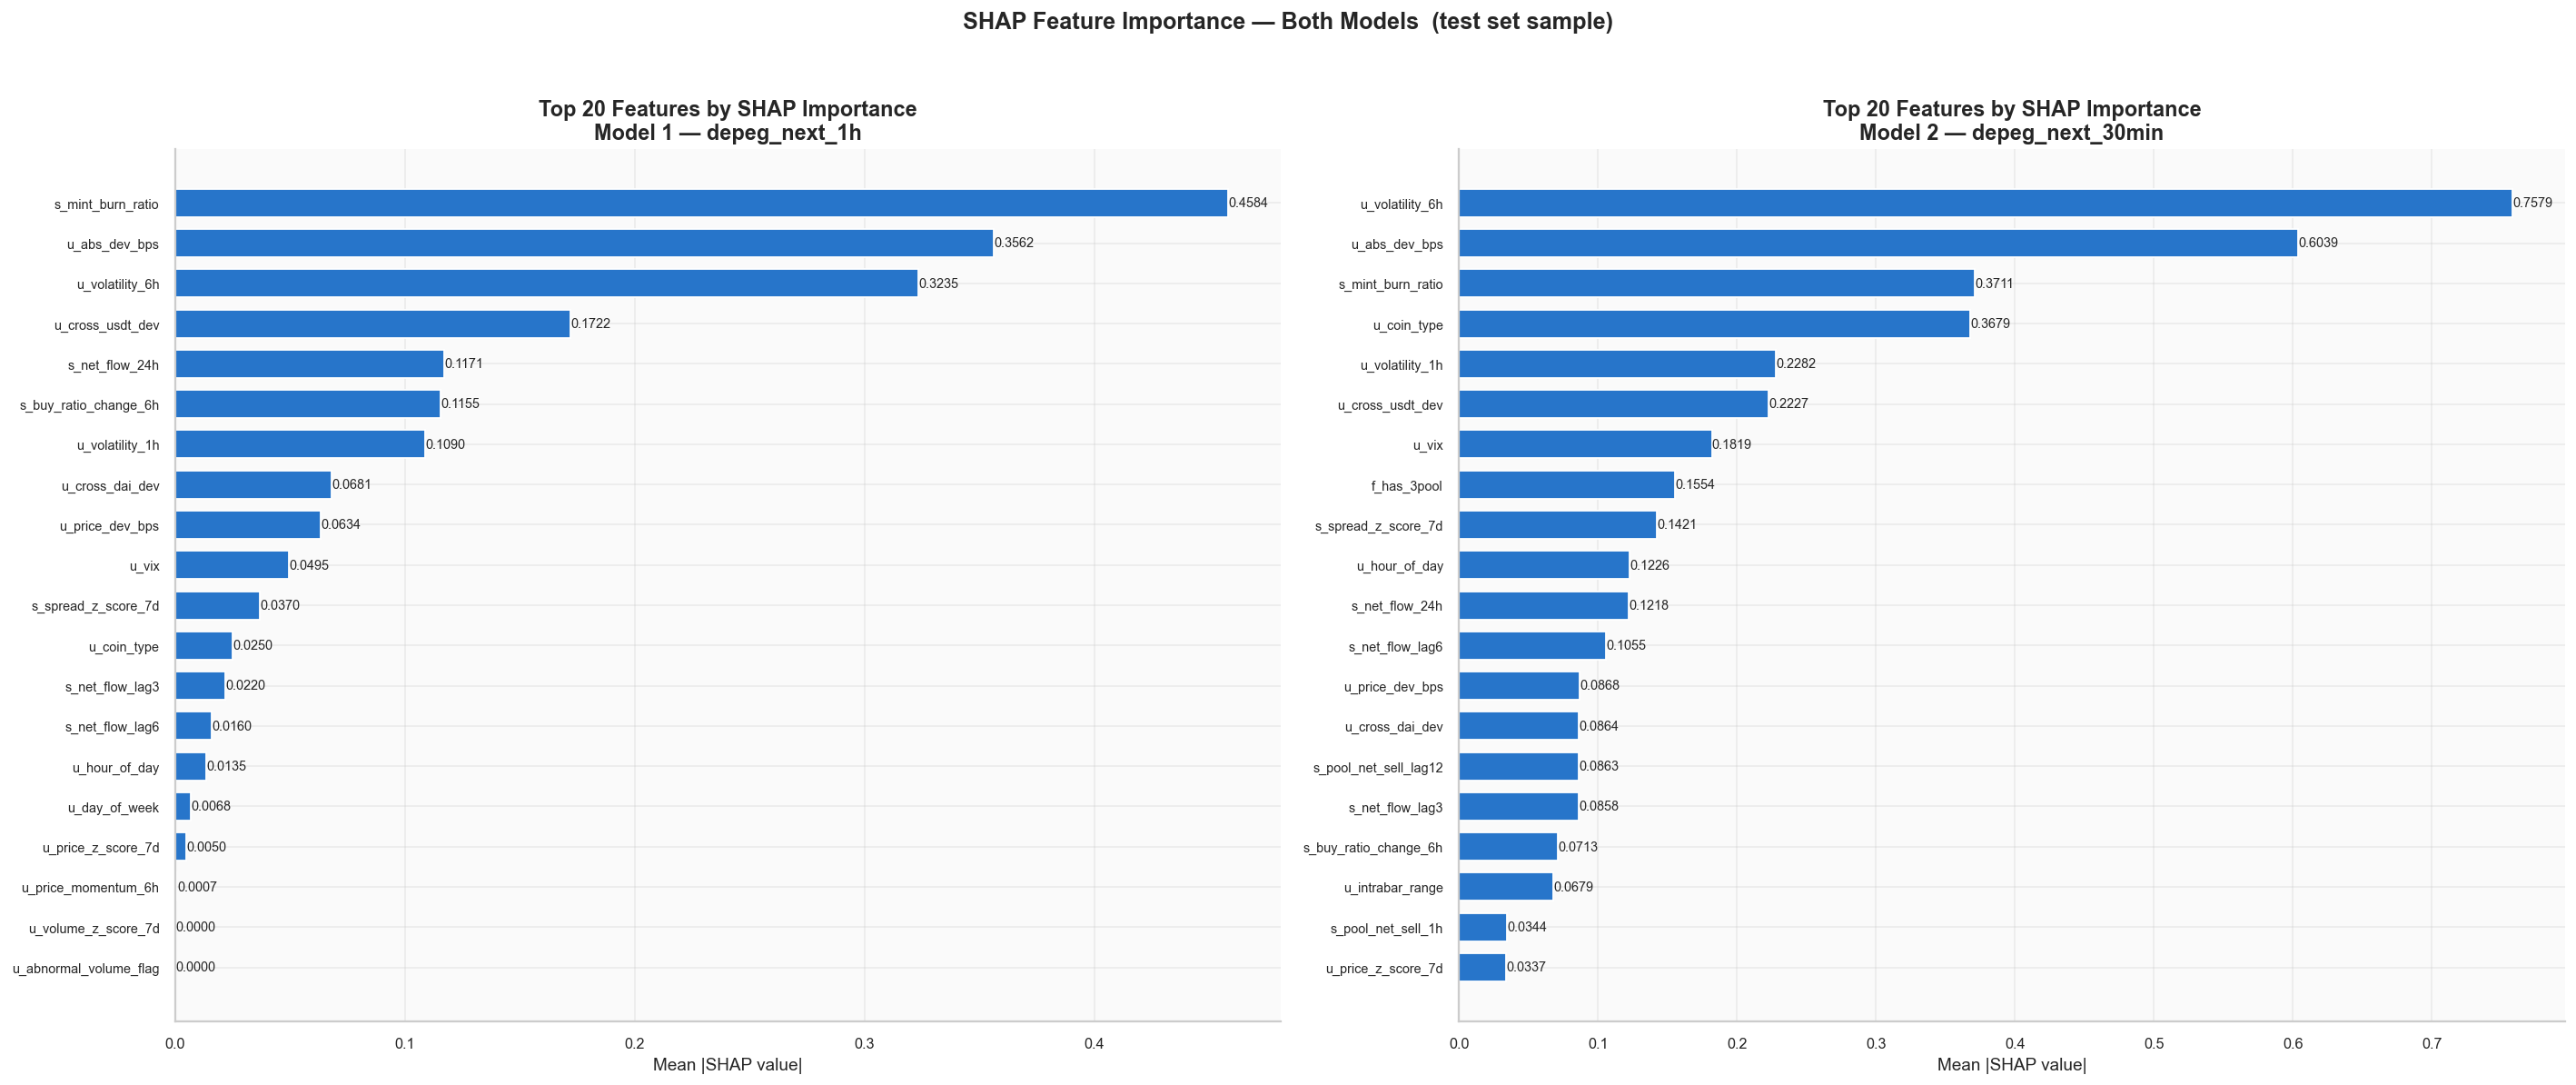

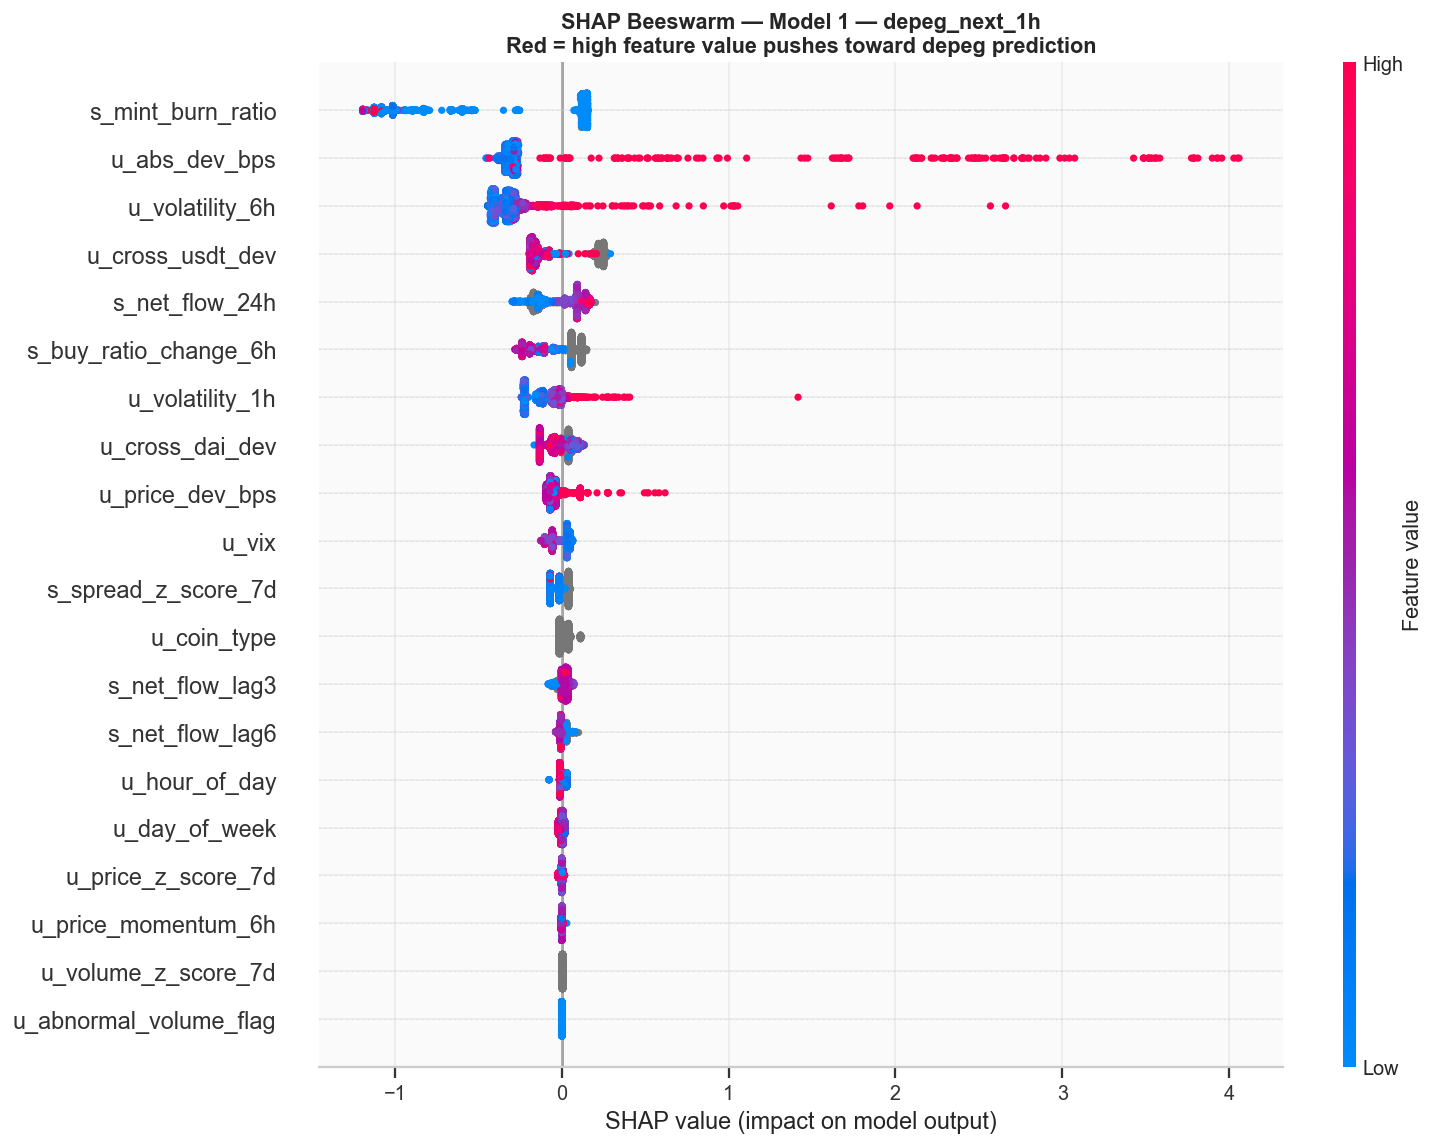

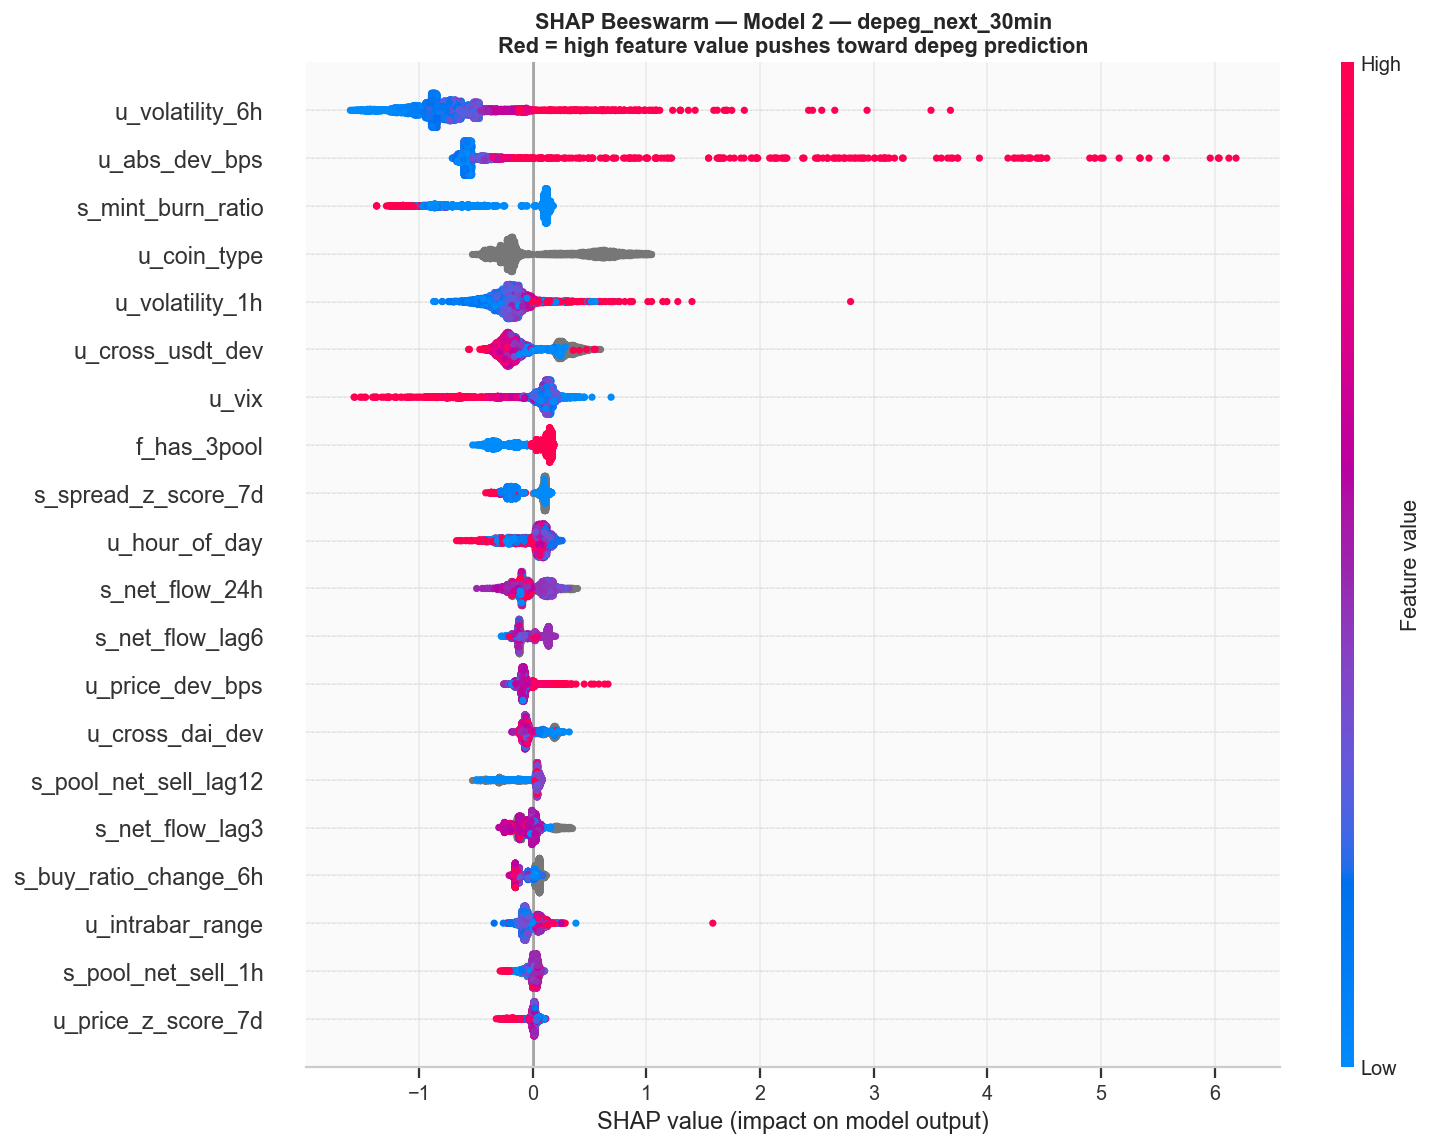

SHAP plots completed in 1.1s


In [19]:
t0 = time.time()

sample_size = min(5000, len(test))
test_sample = test.sample(n=sample_size, random_state=42)
X_sample    = test_sample[all_input]

# compute SHAP for both models
explainer_1h = shap.TreeExplainer(model_1h)
shap_vals_1h = explainer_1h.shap_values(X_sample)

explainer_2  = shap.TreeExplainer(model_2)
shap_vals_2  = explainer_2.shap_values(X_sample)

print(f'SHAP computed on {sample_size:,} test rows for both models')
print(f'Completed in {time.time()-t0:.1f}s')

# %%
t0 = time.time()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, shap_vals, model_name, plot_num in [
    (axes[0], shap_vals_1h, 'Model 1 — depeg_next_1h',    '36a'),
    (axes[1], shap_vals_2,  'Model 2 — depeg_next_30min',  '36b'),
]:
    shap_importance = pd.DataFrame({
        'feature':    all_input,
        'importance': np.abs(shap_vals).mean(axis=0),
    }).sort_values('importance', ascending=True).tail(20)

    bars = ax.barh(
        shap_importance['feature'],
        shap_importance['importance'],
        color=ACCENT, edgecolor='white', height=0.7
    )
    for b in bars:
        ax.text(b.get_width()+0.0002,
                b.get_y()+b.get_height()/2,
                f'{b.get_width():.4f}',
                va='center', fontsize=8)
    ax.set(xlabel='Mean |SHAP value|', ylabel='',
           title=f'Top 20 Features by SHAP Importance\n{model_name}')
    ax.tick_params(axis='y', labelsize=8)
    sns.despine(ax=ax)

fig.suptitle('SHAP Feature Importance — Both Models  (test set sample)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# beeswarm plots 
for shap_vals, model_name, fname in [
    (shap_vals_1h, 'Model 1 — depeg_next_1h',   '37a_shap_beeswarm_1h.png'),
    (shap_vals_2,  'Model 2 — depeg_next_30min', '37b_shap_beeswarm_30min.png'),
]:
    plt.figure(figsize=(12, 9))
    shap.summary_plot(shap_vals, X_sample,
                      feature_names=all_input, show=False,
                      max_display=20, plot_size=None)
    plt.title(f'SHAP Beeswarm — {model_name}\n'
              'Red = high feature value pushes toward depeg prediction',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f'SHAP plots completed in {time.time()-t0:.1f}s')

## 14. Risk Tier Mapping

In [20]:
t0 = time.time()

def assign_risk_tier(prob_1h, prob_30min):
    if prob_1h >= 0.30 or prob_30min >= 0.40:
        return 'HIGH'
    elif prob_1h >= 0.10 or prob_30min >= 0.15:
        return 'ELEVATED'
    else:
        return 'LOW'

test = test.copy()
test['prob_1h']    = test_prob_1h_cal
test['prob_30min'] = test_prob_2_cal
test['risk_tier']  = [
    assign_risk_tier(p1, p2)
    for p1, p2 in zip(test_prob_1h_cal, test_prob_2_cal)
]

# rescore test rows directly using the fitted isolation forest
# avoids index alignment issues from the coin stratified split
test_pos_idx = np.where(df.index.isin(test.index) & 
                        df['coin'].isin(test['coin'].unique()))[0]

# most reliable approach: rescore the test rows directly
test_u_feats = [c for c in feat_cols 
                if c.startswith('u_') 
                and c != 'u_coin_type'
                and df[c].notna().any()]

test_raw_scores = iso_forest.decision_function(
    test[test_u_feats].fillna(df[test_u_feats].median())
)
test['anomaly_score'] = (
    100 * (1 - (test_raw_scores - test_raw_scores.min()) /
           (test_raw_scores.max() - test_raw_scores.min()))
)
test['anomaly_flag'] = (test['anomaly_score'] >= 80).astype(int)

tier_counts = test['risk_tier'].value_counts()
print('Risk tier distribution on test set:')
for tier in ['HIGH', 'ELEVATED', 'LOW']:
    n = tier_counts.get(tier, 0)
    print(f'  {tier:<10s}: {n:>8,}  ({n/len(test)*100:.2f}%)')

print(f'\nRisk tier assignment completed in {time.time()-t0:.1f}s')

Risk tier distribution on test set:
  HIGH      :       16  (0.00%)
  ELEVATED  :      827  (0.18%)
  LOW       :  464,370  (99.82%)

Risk tier assignment completed in 1.3s


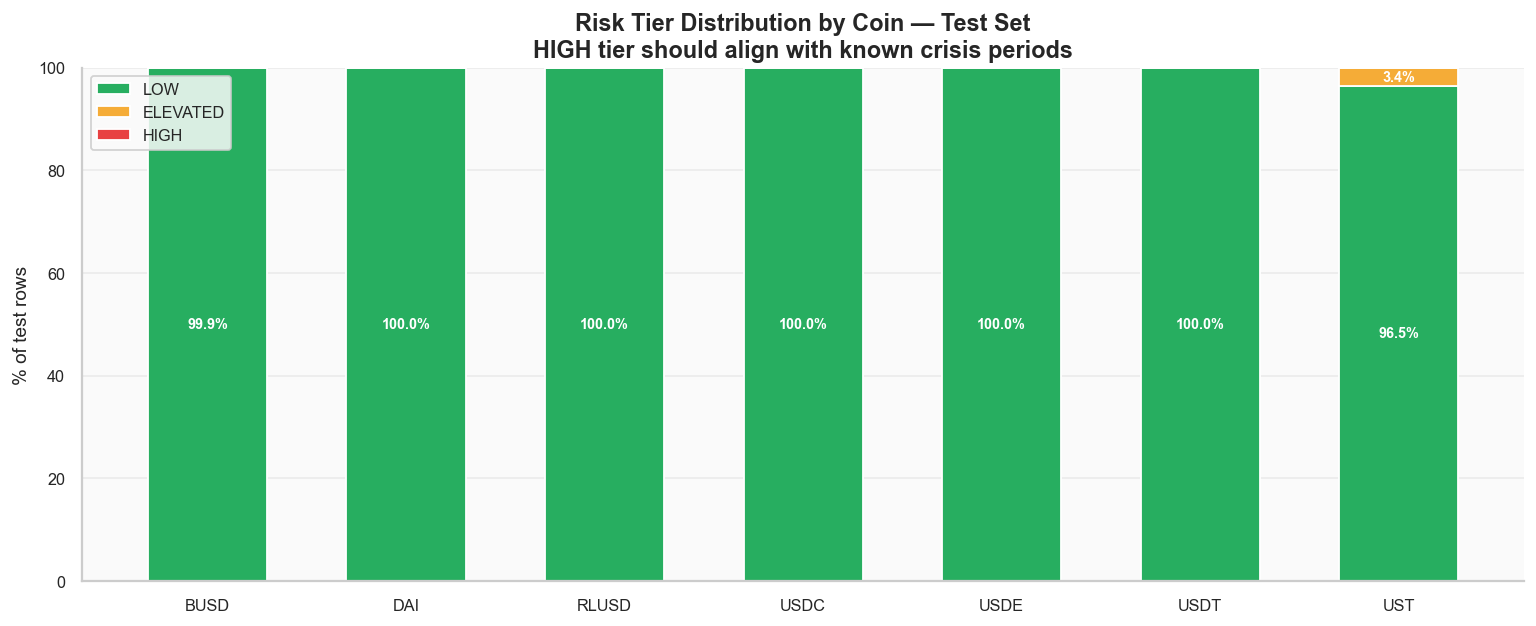

Completed in 0.1s


In [21]:
t0 = time.time()

tier_by_coin = (
    test.groupby(['coin', 'risk_tier'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=['LOW', 'ELEVATED', 'HIGH'], fill_value=0)
)
tier_pct = tier_by_coin.div(tier_by_coin.sum(axis=1), axis=0) * 100

TIER_COLORS = {'LOW': GREEN, 'ELEVATED': ORANGE, 'HIGH': RED}

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(tier_pct))
for tier in ['LOW', 'ELEVATED', 'HIGH']:
    vals = tier_pct[tier].values
    bars = ax.bar(
        [c.upper() for c in tier_pct.index], vals, bottom=bottom,
        color=TIER_COLORS[tier], label=tier, edgecolor='white', width=0.6
    )
    for bar, val in zip(bars, vals):
        if val > 3:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_y()+bar.get_height()/2,
                    f'{val:.1f}%', ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')
    bottom += vals

ax.set(ylabel='% of test rows', xlabel='',
       title='Risk Tier Distribution by Coin — Test Set\n'
             'HIGH tier should align with known crisis periods')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

print(f'Completed in {time.time()-t0:.1f}s')

## 15. Save Models and Predictions

In [23]:
t0 = time.time()

model_1h.save_model(str(MODELS_DIR / "catboost_1h.cbm"))
model_2.save_model(str(MODELS_DIR  / "catboost_30min.cbm"))

with open(MODELS_DIR / "calibrator_1h.pkl",    "wb") as f: pickle.dump(calibrator_1h, f)
with open(MODELS_DIR / "calibrator_30min.pkl", "wb") as f: pickle.dump(calibrator_2,  f)
with open(MODELS_DIR / "isolation_forest.pkl", "wb") as f: pickle.dump(iso_forest,    f)

thresholds_record = pd.DataFrame([{
    "model":     "catboost_1h",
    "target":    TARGET_1H,
    "threshold": threshold_1h,
    "val_f2":    best_f2_1h,
}, {
    "model":     "catboost_30min",
    "target":    TARGET_2,
    "threshold": threshold_2,
    "val_f2":    best_f2_2,
}])
thresholds_record.to_parquet(MODELS_DIR / "thresholds.parquet", index=False)

pred_cols = ["coin", "depeg", TARGET_1H, TARGET_2,
             "prob_1h", "prob_30min", "risk_tier",
             "anomaly_score", "anomaly_flag"]
test[pred_cols].to_parquet(PREDS_DIR / "predictions_test.parquet")

local_outputs = [
    MODELS_DIR / "catboost_1h.cbm",
    MODELS_DIR / "catboost_30min.cbm",
    MODELS_DIR / "calibrator_1h.pkl",
    MODELS_DIR / "calibrator_30min.pkl",
    MODELS_DIR / "isolation_forest.pkl",
    MODELS_DIR / "thresholds.parquet",
    PREDS_DIR  / "predictions_test.parquet",
]
print("Saved files:")
for p in local_outputs:
    size = Path(p).stat().st_size / 1e6
    print(f"  {Path(p).name:<40s} {size:.1f} MB")

print(f"All outputs saved in {time.time()-t0:.1f}s")

Saved files:
  catboost_1h.cbm                          0.1 MB
  catboost_30min.cbm                       0.2 MB
  calibrator_1h.pkl                        0.0 MB
  calibrator_30min.pkl                     0.0 MB
  isolation_forest.pkl                     1.6 MB
  thresholds.parquet                       0.0 MB
  predictions_test.parquet                 12.3 MB
All outputs saved in 0.1s


## 16. Summary

In [24]:
# val was overwritten during the LOEO loop — recover the count from the probability array
n_val = val_prob_1h_cal.shape[0]

In [25]:
print('=' * 72)
print('  MODELLING SUMMARY')
print('=' * 72)

# val was overwritten during the LOEO loop — use pre-computed metrics
val_ap_1h = average_precision_score(
    val_prob_1h_cal > threshold_1h,
    val_prob_1h_cal
) if hasattr(val_prob_1h_cal, '__len__') else best_f2_1h

print(f'''
ARCHITECTURE
  Model 1:  CatBoostClassifier  ->  depeg_next_1h    (1-hour horizon)
  Model 2:  CatBoostClassifier  ->  depeg_next_30min (30-min horizon)
  Novelty:  IsolationForest     ->  anomaly_flag     (novel conditions)

SPLIT
  Coin-stratified chronological 70 / 15 / 15
  Every coin represented in all three sets
  Train:  {len(train):,} rows
  Val:    {n_val:,} rows
  Test:   {len(test):,} rows

TRAINING
  Features:      {len(feat_cols)} numeric + 1 categorical
  Class weights: auto_class_weights=Balanced
  Coin weights:  episode-proportional (DAI=2.28x, USDT=0.97x)

THRESHOLDS  (F2-optimised on validation set)
  Model 1:  {threshold_1h}  (val F2={best_f2_1h:.4f})
  Model 2:  {threshold_2}  (val F2={best_f2_2:.4f})

VALIDATION AUC-PR
  Model 1:  {overall_1h["ap"]:.4f}
  Model 2:  {overall_2["ap"]:.4f}

FINAL TEST SET
  Model 1 AUC-PR:  {overall_1h["ap"]:.4f}   F2: {overall_1h["f2"]:.4f}
  Model 2 AUC-PR:  {overall_2["ap"]:.4f}    F2: {overall_2["f2"]:.4f}

LOEO EVENTS TESTED
''')

for r in loeo_results:
    print(f"  {r['event']:<35s} "
          f"AP_1h={r['ap_1h']:.4f}  Lead={r['lead_1h_h']:.1f}h")


  MODELLING SUMMARY

ARCHITECTURE
  Model 1:  CatBoostClassifier  ->  depeg_next_1h    (1-hour horizon)
  Model 2:  CatBoostClassifier  ->  depeg_next_30min (30-min horizon)
  Novelty:  IsolationForest     ->  anomaly_flag     (novel conditions)

SPLIT
  Coin-stratified chronological 70 / 15 / 15
  Every coin represented in all three sets
  Train:  2,170,980 rows
  Val:    465,212 rows
  Test:   465,213 rows

TRAINING
  Features:      25 numeric + 1 categorical
  Class weights: auto_class_weights=Balanced
  Coin weights:  episode-proportional (DAI=2.28x, USDT=0.97x)

THRESHOLDS  (F2-optimised on validation set)
  Model 1:  0.05  (val F2=0.5565)
  Model 2:  0.0864  (val F2=0.6069)

VALIDATION AUC-PR
  Model 1:  0.3174
  Model 2:  0.4139

FINAL TEST SET
  Model 1 AUC-PR:  0.3174   F2: 0.5355
  Model 2 AUC-PR:  0.4139    F2: 0.4816

LOEO EVENTS TESTED

  Oct 2018 USDT Reserve Scare         AP_1h=1.0000  Lead=0.0h
  Mar 2020 Black Thursday             AP_1h=0.6002  Lead=1.2h
  May 2022 UST